# Home Cage Example Recordings
This notebook plots the first 30 seconds after each home cage bout introduction and overlays Investigation epochs on top of the DA trace.
It is set up so you can:
- load either NAc or mPFC recordings,
- view multiple subjects in the same figure,
- compare home cage bouts side by side,
- keep the investigation overlay style consistent with your existing plotting functions.


In [6]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'Home_Cage' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from experiment_class import Experiment
from hc_extension import *
from bouts_extension import *


In [7]:
# Update these paths if your data live somewhere else.
NAC_EXPERIMENT_PATH = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac"
NAC_CSV_PATH = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac_csvs"
MPFC_EXPERIMENT_PATH = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\mpfc"
MPFC_CSV_PATH = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\mpfc_csvs"
BOUT_DEFINITIONS = [
    {'prefix': 'Short_Term', 'introduced': 'Short_Term_Introduced', 'removed': 'Short_Term_Removed'},
    {'prefix': 'Long_Term', 'introduced': 'Long_Term_Introduced', 'removed': 'Long_Term_Removed'},
    {'prefix': 'Novel', 'introduced': 'Novel_Introduced', 'removed': 'Novel_Removed'},
]
BOUTS_TO_PLOT = ['Short_Term-1', 'Short_Term-2', 'Long_Term-1', 'Novel-1']
BEHAVIOR_COLORS = {
    'Investigation': 'dodgerblue',
    'Approach': 'green',
    'Defeat': 'red',
    'Aggression': 'red',
}


In [8]:
def load_hc_experiment(region='nac'):
    """
    Load and preprocess one Home Cage experiment.
    region: 'nac' or 'mpfc'
    """
    region = region.lower()
    if region == 'nac':
        experiment_path = NAC_EXPERIMENT_PATH
        csv_path = NAC_CSV_PATH
    elif region == 'mpfc':
        experiment_path = MPFC_EXPERIMENT_PATH
        csv_path = MPFC_CSV_PATH
    else:
        raise ValueError("region must be 'nac' or 'mpfc'")
    exp = Experiment(experiment_path, csv_path)
    exp.default_batch_process()
    exp.group_extract_manual_annotations(bout_definitions=BOUT_DEFINITIONS, first_only=False)
    return exp


In [9]:
# Choose which regions to load and process.
# Options inside the list: 'nac', 'mpfc'
REGIONS_TO_LOAD = ['nac', 'mpfc']
experiments = {region: load_hc_experiment(region) for region in REGIONS_TO_LOAD}
DEFAULT_REGION = REGIONS_TO_LOAD[0]


Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n5-240823-085032\Notes.txt
read from t=0s to t=1789.26s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n6-240823-101436\Notes.txt
read from t=0s to t=1793.07s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\n7-240824-062103\Notes.txt
read from t=0s to t=1803.56s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn1-250120-063024\Notes.txt
read from t=0s to t=1833.87s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn2-250120-072910\Notes.txt
read from t=0s to t=1774.16s
Found Synapse note file: C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Home_Cage\nac\nn3-250121-074834\Notes.txt
read f

In [10]:
subject_table = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    'region': region.upper(),
                    'trial_name': trial_name,
                    'subject_name': trial.subject_name,
                }
                for trial_name, trial in experiment.trials.items()
            ]
        )
        for region, experiment in experiments.items()
    ],
    ignore_index=True,
).sort_values(['region', 'subject_name', 'trial_name']).reset_index(drop=True)

subject_table

,region,trial_name,subject_name
0,MPFC,p1-240508-084607,p1
1,MPFC,p2-240508-101128,p2
2,MPFC,p3-240509-070801,p3
3,MPFC,p5-240823-093250,p5
4,MPFC,p6-240823-105552,p6
5,MPFC,p7-240824-053845,p7
6,MPFC,p8-240824-070451,p8
7,MPFC,pp1-250120-094415,pp1
8,MPFC,pp2-250121-123301,pp2
9,MPFC,pp3-250121-055222,pp3


In [11]:
def build_subject_trial_map(experiment):
    return {
        trial.subject_name: trial_name
        for trial_name, trial in experiment.trials.items()
    }


def get_trial_by_subject(experiment, subject_name):
    subject_to_trial = build_subject_trial_map(experiment)
    if subject_name not in subject_to_trial:
        available = sorted(subject_to_trial)
        raise KeyError(f"Subject '{subject_name}' not found. Available subjects: {available}")
    return experiment.trials[subject_to_trial[subject_name]]


def get_bout_bounds_df(experiment):
    return experiment.get_bout_boundaries_df(BOUT_DEFINITIONS)


def plot_bout_intro_examples(
    experiment,
    subject_names,
    bouts=None,
    window_s=30,
    behavior_name='Investigation',
    signal_name='zscore',
    sharey=True,
    linewidth=1.5,
    overlay_alpha=0.25,
    region_label=None,
):
    """
    Plot the first `window_s` seconds after each bout introduction for multiple subjects.

    Rows = subjects
    Columns = bouts
    """
    if bouts is None:
        bouts = BOUTS_TO_PLOT

    if isinstance(subject_names, str):
        subject_names = [subject_names]

    bout_bounds_df = get_bout_bounds_df(experiment)
    n_rows = len(subject_names)
    n_cols = len(bouts)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.2 * n_cols, 2.8 * n_rows),
        sharex=True,
        sharey=sharey,
        squeeze=False,
    )

    behavior_color = BEHAVIOR_COLORS.get(behavior_name, 'dodgerblue')

    for row_idx, subject_name in enumerate(subject_names):
        trial = get_trial_by_subject(experiment, subject_name)
        timestamps = np.asarray(trial.timestamps)
        signal = np.asarray(getattr(trial, signal_name))

        subject_bounds = bout_bounds_df[bout_bounds_df['Subject'] == subject_name]

        for col_idx, bout in enumerate(bouts):
            ax = axes[row_idx, col_idx]
            bout_row = subject_bounds[subject_bounds['Bout'] == bout]

            if bout_row.empty:
                ax.text(0.5, 0.5, f'No {bout}', transform=ax.transAxes, ha='center', va='center')
                ax.set_xlim(0, window_s)
                ax.set_title(f'{subject_name} | {bout}')
                continue

            bout_start = float(bout_row.iloc[0]['Bout_Start_s'])
            bout_end = float(bout_row.iloc[0]['Bout_End_s'])
            window_end = min(bout_start + window_s, float(timestamps[-1]))

            mask = (timestamps >= bout_start) & (timestamps <= window_end)
            if not np.any(mask):
                ax.text(0.5, 0.5, 'No signal in window', transform=ax.transAxes, ha='center', va='center')
                ax.set_xlim(0, window_s)
                ax.set_title(f'{subject_name} | {bout}')
                continue

            x = timestamps[mask] - bout_start
            y = signal[mask]
            ax.plot(x, y, color='black', linewidth=linewidth)

            if trial.behaviors is not None and not trial.behaviors.empty:
                behavior_df = trial.behaviors.copy()
                behavior_df = behavior_df[
                    (behavior_df['Behavior'] == behavior_name)
                    & (behavior_df['Bout'] == bout)
                ]

                for _, behavior_row in behavior_df.iterrows():
                    event_start = max(float(behavior_row['Event_Start']), bout_start)
                    event_end = min(float(behavior_row['Event_End']), window_end)
                    if event_end <= event_start:
                        continue
                    ax.axvspan(
                        event_start - bout_start,
                        event_end - bout_start,
                        color=behavior_color,
                        alpha=overlay_alpha,
                    )

            ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
            if bout_end <= window_end:
                ax.axvline(bout_end - bout_start, color='gray', linestyle='--', linewidth=1)

            ax.set_xlim(0, window_s)
            ax.set_title(f'{subject_name} | {bout}')
            ax.set_xlabel('Seconds from bout introduction')
            if col_idx == 0:
                ax.set_ylabel(signal_name)

    legend_handles = [
        Line2D([0], [0], color='black', linewidth=linewidth, label=signal_name),
        Patch(facecolor=behavior_color, alpha=overlay_alpha, label=behavior_name),
        Line2D([0], [0], color='crimson', linestyle='--', linewidth=1, label='Bout intro'),
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='Bout removal'),
    ]
    fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
    region_title = region_label.upper() if region_label is not None else 'HC'
    fig.suptitle(f'{region_title} example recordings: first {window_s} s after bout introduction', y=1.08)
    plt.tight_layout()
    plt.show()


def collect_example_windows(
    experiment,
    subject_names,
    bouts=None,
    window_s=30,
    behavior_name='Investigation',
    signal_name='zscore',
):
    """Collect bout-introduction windows so multiple exported examples can share one scale."""
    if bouts is None:
        bouts = BOUTS_TO_PLOT

    if isinstance(subject_names, str):
        subject_names = [subject_names]

    bout_bounds_df = get_bout_bounds_df(experiment)
    examples = []

    for subject_name in subject_names:
        trial = get_trial_by_subject(experiment, subject_name)
        timestamps = np.asarray(trial.timestamps)
        signal = np.asarray(getattr(trial, signal_name))
        subject_bounds = bout_bounds_df[bout_bounds_df['Subject'] == subject_name]

        for bout in bouts:
            bout_row = subject_bounds[subject_bounds['Bout'] == bout]
            if bout_row.empty:
                continue

            bout_start = float(bout_row.iloc[0]['Bout_Start_s'])
            window_end = min(bout_start + window_s, float(timestamps[-1]))
            mask = (timestamps >= bout_start) & (timestamps <= window_end)
            if not np.any(mask):
                continue

            x = timestamps[mask] - bout_start
            y = signal[mask]

            spans = []
            if trial.behaviors is not None and not trial.behaviors.empty:
                behavior_df = trial.behaviors.copy()
                behavior_df = behavior_df[
                    (behavior_df['Behavior'] == behavior_name)
                    & (behavior_df['Bout'] == bout)
                ]
                for _, behavior_row in behavior_df.iterrows():
                    event_start = max(float(behavior_row['Event_Start']), bout_start)
                    event_end = min(float(behavior_row['Event_End']), window_end)
                    if event_end <= event_start:
                        continue
                    spans.append((event_start - bout_start, event_end - bout_start))

            examples.append({
                'subject_name': subject_name,
                'bout': bout,
                'x': x,
                'y': y,
                'spans': spans,
            })

    return examples


def save_figure_ready_examples(
    experiment,
    subject_names,
    bouts=None,
    window_s=30,
    behavior_name='Investigation',
    signal_name='zscore',
    investigation_color='#15616F',
    overlay_alpha=0.28,
    trace_color='black',
    linewidth=1.8,
    figsize=(4.8, 2.4),
    output_dir='example_recording_exports',
    file_prefix='',
    transparent=True,
    dpi=300,
    pad_inches=0,
    region_label=None,
):
    """
    Save figure-ready, axis-free examples as individual files.

    Every saved panel uses the same x/y scale across the selected examples.
    """
    examples = collect_example_windows(
        experiment=experiment,
        subject_names=subject_names,
        bouts=bouts,
        window_s=window_s,
        behavior_name=behavior_name,
        signal_name=signal_name,
    )

    if not examples:
        raise ValueError('No valid examples found for the requested subjects/bouts.')

    y_min = min(np.nanmin(example['y']) for example in examples)
    y_max = max(np.nanmax(example['y']) for example in examples)
    if np.isclose(y_min, y_max):
        y_pad = 1.0
    else:
        y_pad = 0.05 * (y_max - y_min)
    y_limits = (y_min - y_pad, y_max + y_pad)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for example in examples:
        fig, ax = plt.subplots(figsize=figsize)

        for start_s, end_s in example['spans']:
            ax.axvspan(start_s, end_s, color=investigation_color, alpha=overlay_alpha, linewidth=0)

        ax.plot(example['x'], example['y'], color=trace_color, linewidth=linewidth)
        ax.set_xlim(0, window_s)
        ax.set_ylim(*y_limits)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(False)
        fig.patch.set_alpha(0 if transparent else 1)
        ax.set_facecolor('none' if transparent else 'white')
        plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

        prefix = f'{file_prefix}_' if file_prefix else ''
        region_prefix = f'{region_label}_' if region_label else ''
        file_name = f"{prefix}{region_prefix}{example['subject_name']}_{example['bout']}_{signal_name}.png"
        save_path = output_dir / file_name
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', pad_inches=pad_inches, transparent=transparent)
        plt.close(fig)
        saved_paths.append(save_path)

    return saved_paths, y_limits


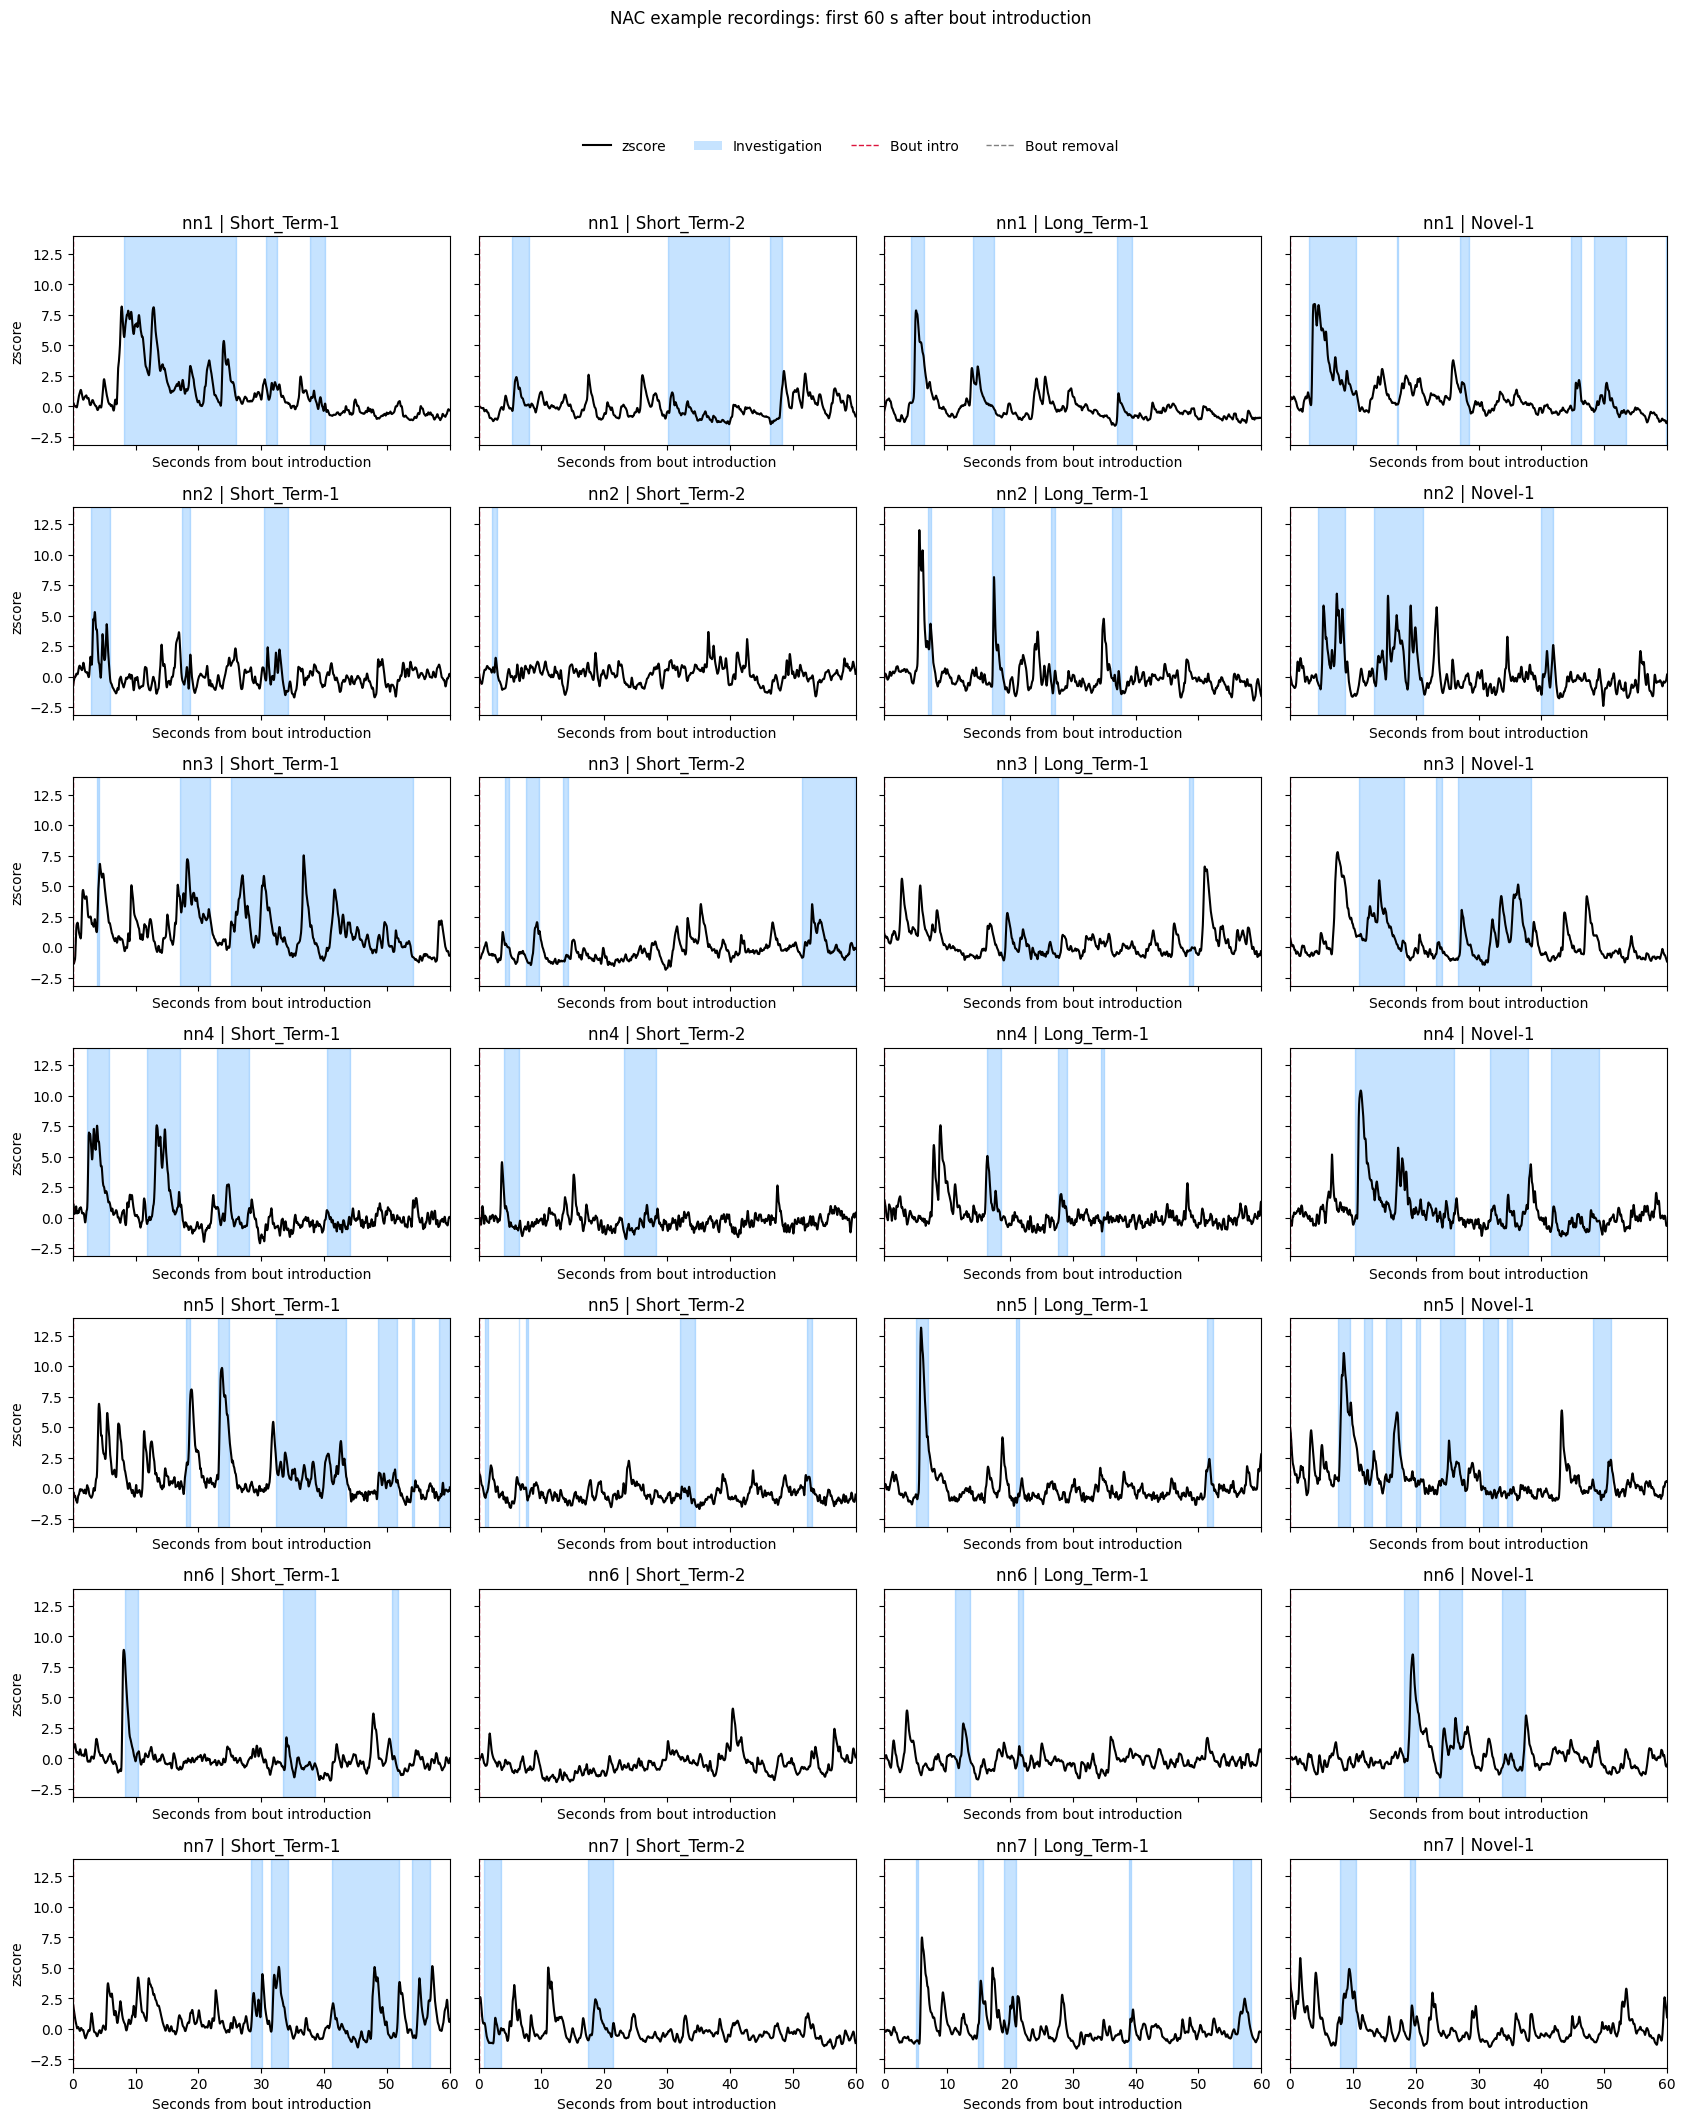

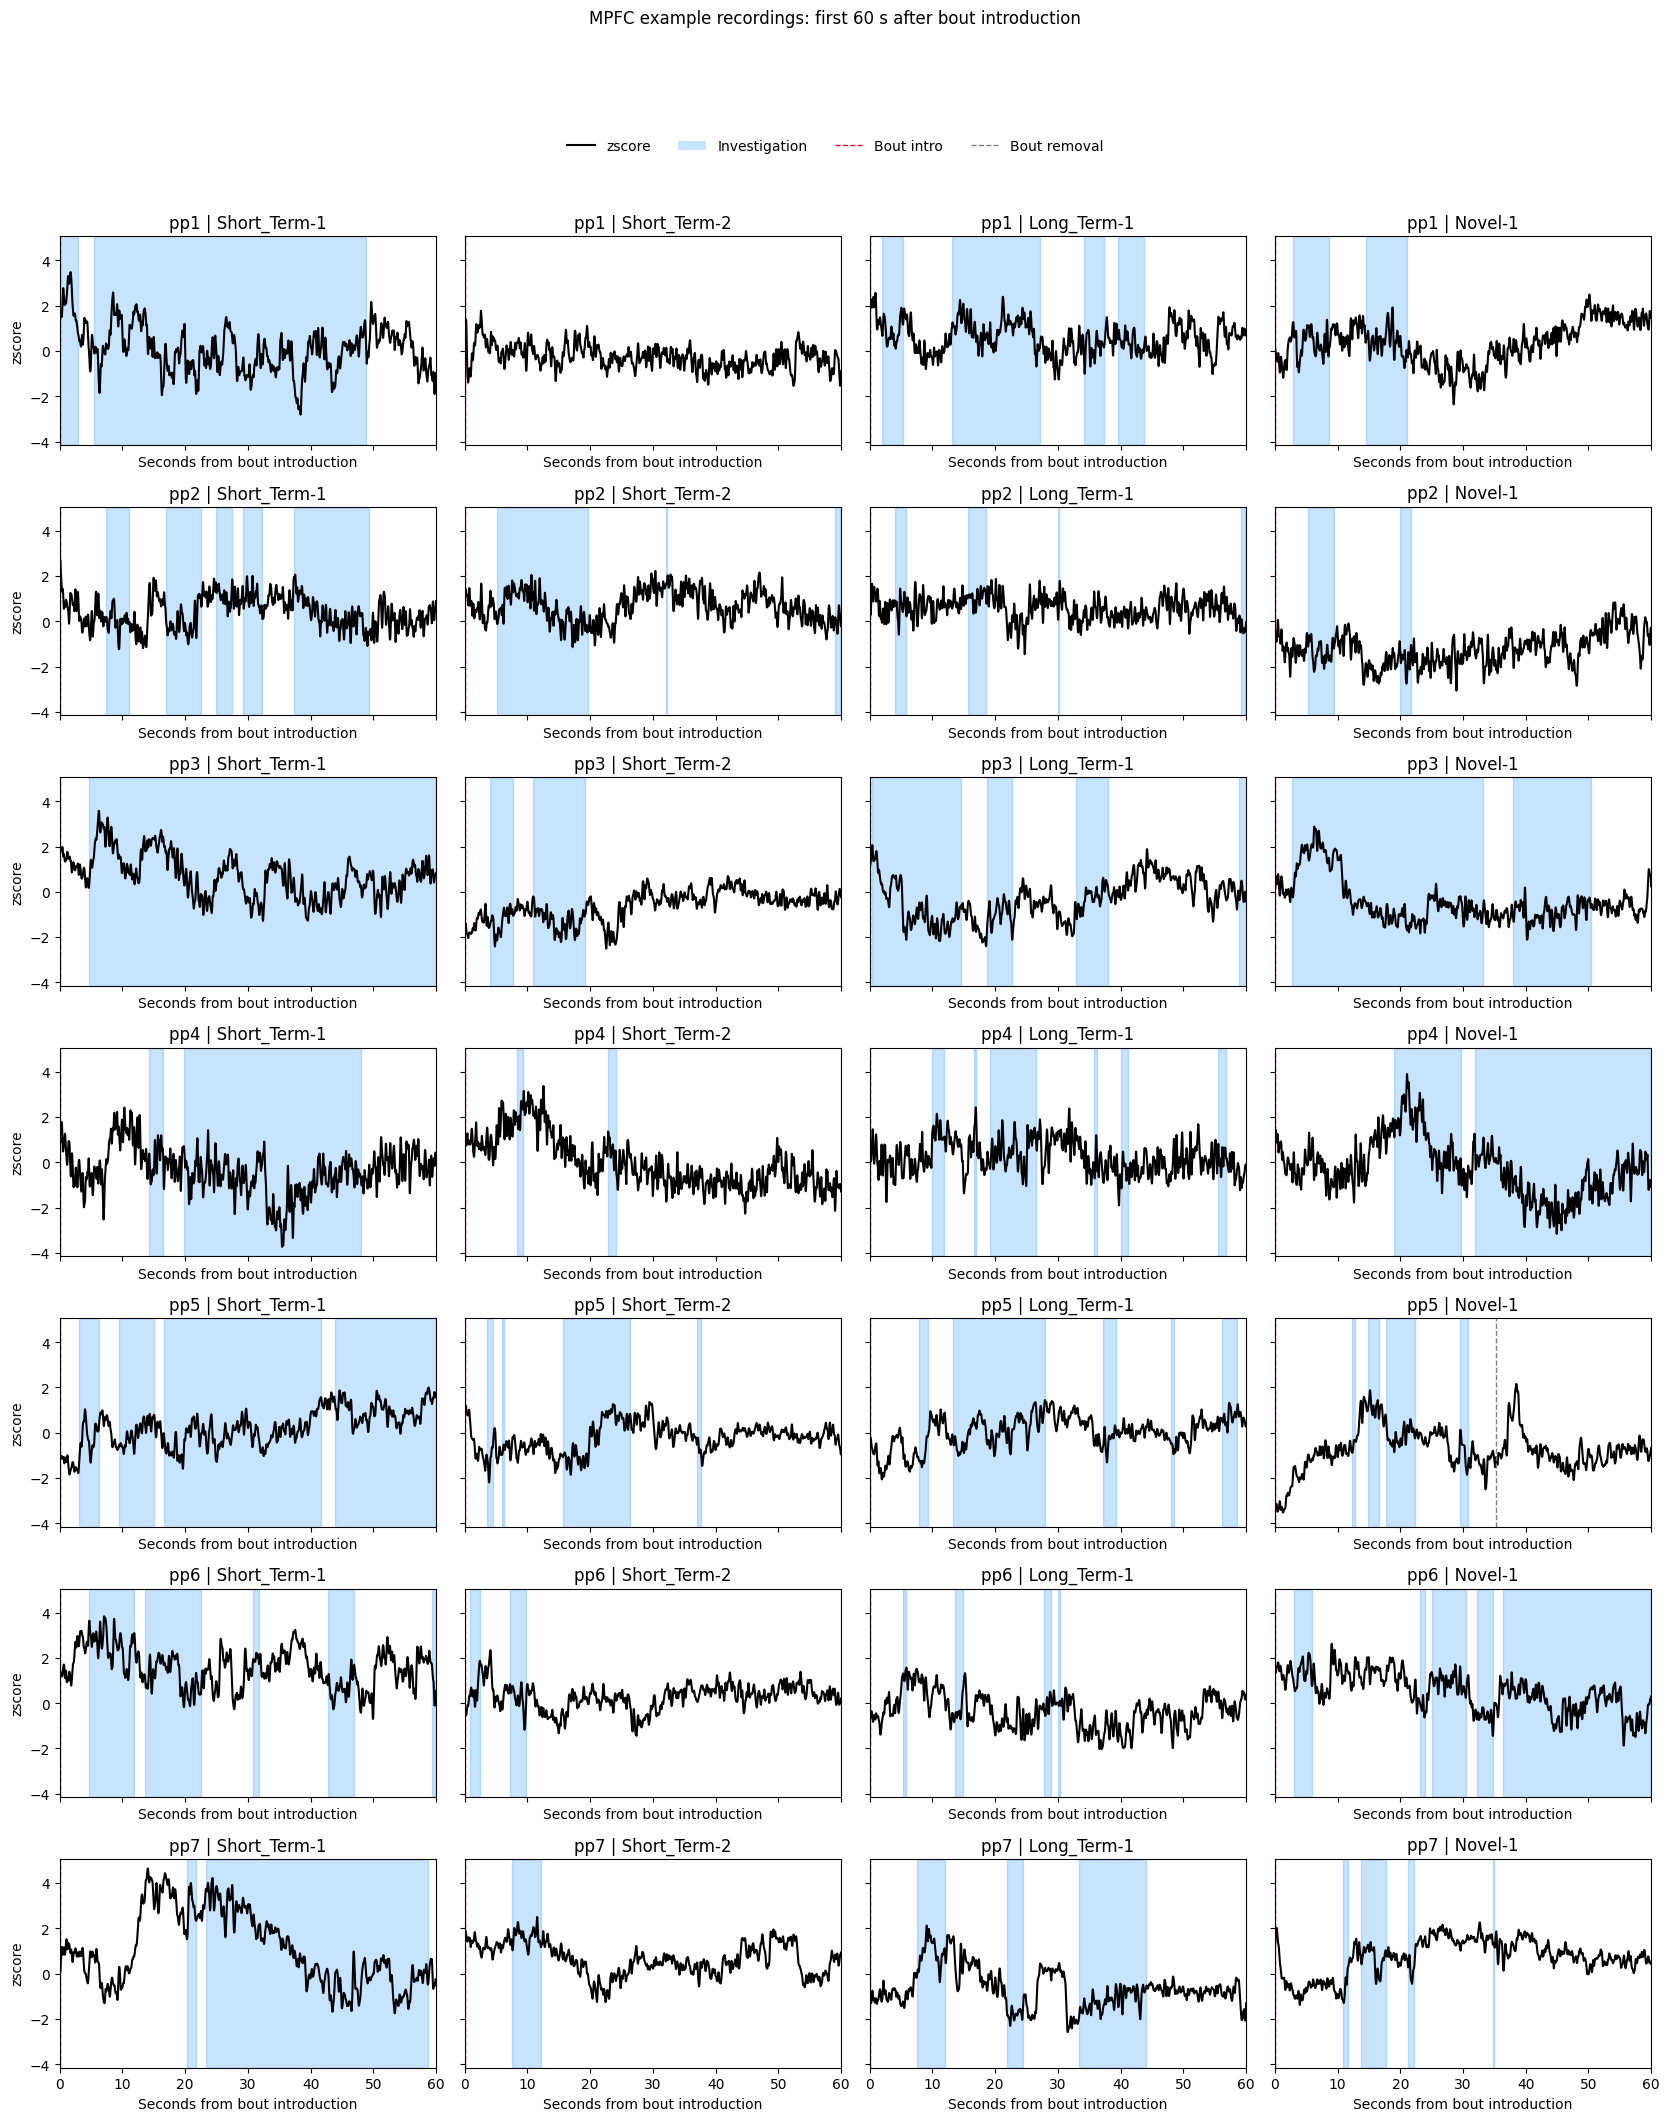

In [12]:
# Pick as many subjects as you want for each region.
subjects_to_plot_by_region = {
    'nac': ['nn1', 'nn2', 'nn3', 'nn4', 'nn5', 'nn6', 'nn7'],
    'mpfc': ['pp1', 'pp2', 'pp3', 'pp4', 'pp5', 'pp6', 'pp7'],
}

for region, experiment in experiments.items():
    subjects_to_plot = subjects_to_plot_by_region.get(region, [])
    if not subjects_to_plot:
        continue
    plot_bout_intro_examples(
        experiment,
        subject_names=subjects_to_plot,
        bouts=BOUTS_TO_PLOT,
        window_s=60,
        behavior_name='Investigation',
        signal_name='zscore',
        sharey=True,
        region_label=region,
    )


In [15]:
# Figure-ready export: no axes, no border, individual files, shared scale.
# Change investigation_hex to any hex color you want.
subjects_to_export_by_region = {
    'nac': ['nn1'],
    'mpfc': ['pp2'],
}
bouts_to_export = ['Short_Term-1', 'Short_Term-2', 'Long_Term-1', 'Novel-1']
investigation_hex = '#1E90FF'
# investigation_hex = '#A6C6D3'

for region, experiment in experiments.items():
    subjects_to_export = subjects_to_export_by_region.get(region, [])
    if not subjects_to_export:
        continue
    saved_paths, shared_y_limits = save_figure_ready_examples(
        experiment,
        subject_names=subjects_to_export,
        bouts=bouts_to_export,
        window_s=60,
        behavior_name='Investigation',
        signal_name='zscore',
        investigation_color=investigation_hex,
        output_dir=Path('figure_ready_examples') / region,
        file_prefix='hc_example',
        transparent=True,
        dpi=300,
        region_label=region,
    )
    print(f'{region.upper()} shared y-limits:', shared_y_limits)
    for path in saved_paths:
        print(path)


NAC shared y-limits: (-2.1037671789956214, 8.879266970149928)
figure_ready_examples\nac\hc_example_nac_nn1_Short_Term-1_zscore.png
figure_ready_examples\nac\hc_example_nac_nn1_Short_Term-2_zscore.png
figure_ready_examples\nac\hc_example_nac_nn1_Long_Term-1_zscore.png
figure_ready_examples\nac\hc_example_nac_nn1_Novel-1_zscore.png
MPFC shared y-limits: (-3.3452957876661418, 2.9865285948665132)
figure_ready_examples\mpfc\hc_example_mpfc_pp2_Short_Term-1_zscore.png
figure_ready_examples\mpfc\hc_example_mpfc_pp2_Short_Term-2_zscore.png
figure_ready_examples\mpfc\hc_example_mpfc_pp2_Long_Term-1_zscore.png
figure_ready_examples\mpfc\hc_example_mpfc_pp2_Novel-1_zscore.png


### Notes
- Change subjects_to_plot_by_region to any set of subjects shown in subject_table.
- Change BOUTS_TO_PLOT if you only want a subset of bouts.
- If you want raw dFF instead of zscore, switch signal_name='dFF'.
- If you want one subject at a time, pass a single string like subject_names='pp1', or use a one-item list inside the region mapping.
- save_figure_ready_examples(...) exports one image per subject/bout with no axes, no ticks, and no visible border.
- Use investigation_color='#HEXCODE' to choose the overlay color.
- All exported files from one call share the same y-scale, which is returned as shared_y_limits.
- If you want a single example only, set one subject in subjects_to_export_by_region and one bout in bouts_to_export, for example {'nac': ['pp1']} and ['Short_Term-1'].
